# Final: Automated Policy Design with Network-Selected Parameters

## Overview
This notebook uses the World3 policy-design workflow from `milestone_part2/part2.ipynb`, but the grid-search parameter set is fixed in advance by `final/candidates_selection.ipynb`.

Adopted grid-search parameters:
- `icor2`
- `pyear`
- `ppgf2`
- `nruf2`

The workflow is:
1. Run baseline and explore candidate sustainability variables
2. Use correlation and discrimination analysis to justify the final sustainability indicators
3. Directly adopt the four grid-search parameters from `final/candidates_selection.ipynb`
4. Define the sustainability score
5. Run the 500-scenario automated grid search over the fixed parameter set
6. Analyse the optimal strategy with sensitivity, trajectories, and heatmap diagnostics


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from itertools import product
warnings.filterwarnings('ignore')
import pyworld3
print('pyworld3 loaded.')


pyworld3 loaded.


In [80]:
def run_world3(pyear=1975, year_max=2100, **constants):
    w3 = pyworld3.World3(year_max=year_max, pyear=pyear)
    w3.init_world3_constants(**constants)
    w3.init_world3_variables()
    w3.set_world3_table_functions()
    w3.set_world3_delay_functions()
    w3.run_world3()
    return w3

def get_time(model):
    return np.arange(model.year_min, model.year_max + model.dt, model.dt)

baseline = run_world3()
t = get_time(baseline)
print(f'Baseline OK. {t[0]:.0f}–{t[-1]:.0f}, {len(t)} steps.')

Baseline OK. 1900–2100, 401 steps.


## Step 1: Explore Variable Behavior in Baseline

We first examine how all output variables behave in the baseline run (2000–2100),
specifically looking at peak-to-2100 collapse magnitude to identify which variables
experience meaningful decline and are therefore candidates for sustainability indicators.

In [81]:
# Analyze key variables for collapse risk
candidate_vars = ['pop', 'nr', 'le', 'ppolx', 'fpc', 'iopc',
                  'io', 'cdr', 'cbr', 'lmf', 'lmhs', 'lmp', 'fce', 'fcaor']

print(f"{'Var':<8} {'2000':>10} {'2050':>10} {'2100':>10} {'PeakDrop%':>10} {'Note'}")
print("-" * 65)

var_stats = {}
for var in candidate_vars:
    arr = getattr(baseline, var)
    v2000 = arr[t >= 2000][0]
    v2050 = arr[t >= 2050][0]
    v2100 = arr[-1]
    peak  = arr.max()
    drop  = (peak - v2100) / (abs(peak) + 1e-9) * 100
    change_pct = (v2100 - v2000) / (abs(v2000) + 1e-9) * 100
    var_stats[var] = {'drop': drop, 'change': change_pct,
                      'v2000': v2000, 'v2050': v2050, 'v2100': v2100}
    note = '<-- large collapse' if drop > 30 else ''
    print(f"{var:<8} {v2000:>10.3f} {v2050:>10.3f} {v2100:>10.3f} {drop:>+9.1f}%  {note}")

Var            2000       2050       2100  PeakDrop% Note
-----------------------------------------------------------------
pop      5643475565.014 6237602834.836 3976857676.148     +43.7%  <-- large collapse
nr       688022094219.748 196045439270.995 152023587005.392     +84.8%  <-- large collapse
le           54.735     38.994     27.763     +54.8%  <-- large collapse
ppolx         3.530      7.592      0.602     +94.5%  <-- large collapse
fpc         495.124    256.573    235.747     +53.4%  <-- large collapse
iopc        351.750     89.381     10.711     +97.3%  <-- large collapse
io       1985092990946.341 557522784556.874 42594878499.226     +98.4%  <-- large collapse
cdr          14.743     28.785     38.136      +0.0%  
cbr          27.236     19.089     30.689      +nan%  
lmf           1.215      1.023      1.005     +17.6%  
lmhs          1.566      1.618      1.218     +32.1%  <-- large collapse
lmp           0.996      0.992      0.999      +0.1%  
fce           0.955     

## Step 2: Correlation Analysis

To avoid double-counting, we compute pairwise correlations between all candidate
variables over 2000–2100. Variables with |r| > 0.85 against an already-selected
indicator are excluded, since they carry redundant information.

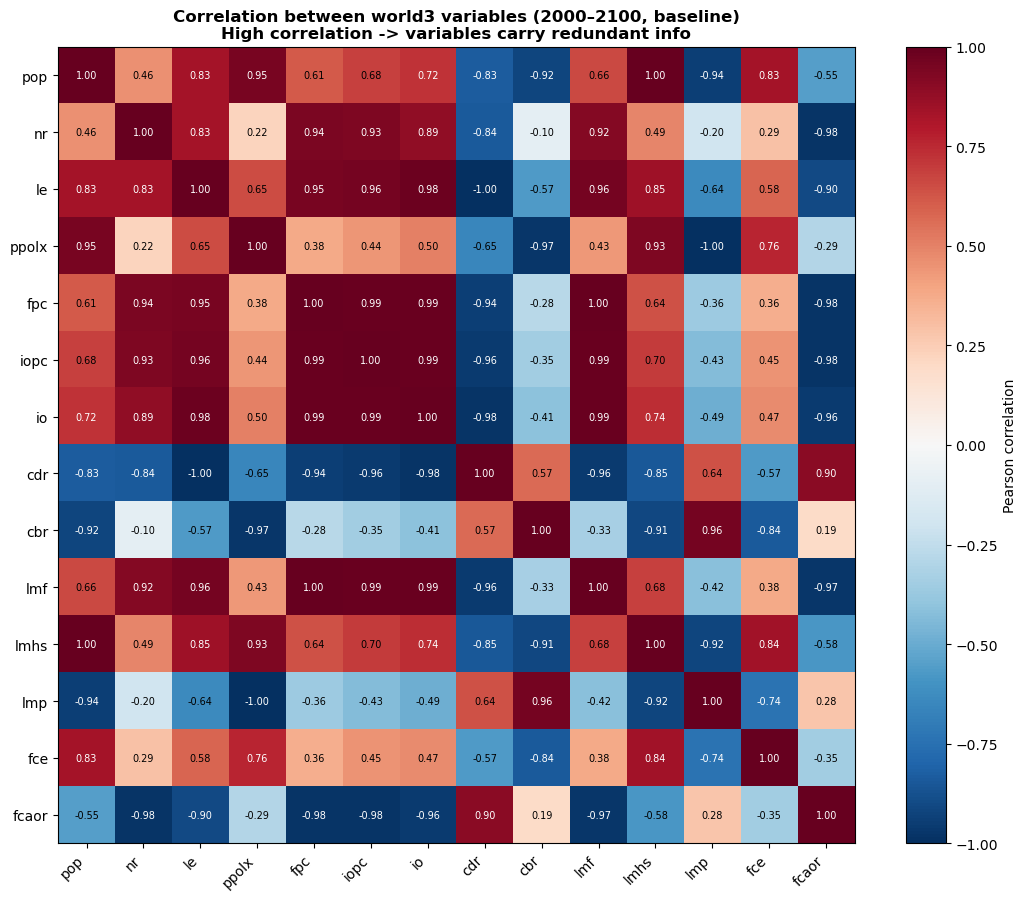


Highly correlated pairs (|r| > 0.85) — avoid using both:
  pop & ppolx: r = 0.95
  pop & cbr: r = -0.92
  pop & lmhs: r = 1.00
  pop & lmp: r = -0.94
  nr & fpc: r = 0.94
  nr & iopc: r = 0.93
  nr & io: r = 0.89
  nr & lmf: r = 0.92
  nr & fcaor: r = -0.98
  le & fpc: r = 0.95
  le & iopc: r = 0.96
  le & io: r = 0.98
  le & cdr: r = -1.00
  le & lmf: r = 0.96
  le & fcaor: r = -0.90
  ppolx & cbr: r = -0.97
  ppolx & lmhs: r = 0.93
  ppolx & lmp: r = -1.00
  fpc & iopc: r = 0.99
  fpc & io: r = 0.99
  fpc & cdr: r = -0.94
  fpc & lmf: r = 1.00
  fpc & fcaor: r = -0.98
  iopc & io: r = 0.99
  iopc & cdr: r = -0.96
  iopc & lmf: r = 0.99
  iopc & fcaor: r = -0.98
  io & cdr: r = -0.98
  io & lmf: r = 0.99
  io & fcaor: r = -0.96
  cdr & lmf: r = -0.96
  cdr & fcaor: r = 0.90
  cbr & lmhs: r = -0.91
  cbr & lmp: r = 0.96
  lmf & fcaor: r = -0.97
  lmhs & lmp: r = -0.92


In [82]:
mask    = t >= 2000
data    = {v: getattr(baseline, v)[mask]
           for v in candidate_vars
           if getattr(baseline, v).shape == t.shape}
df_corr = pd.DataFrame(data).corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(df_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(df_corr.columns)))
ax.set_yticks(range(len(df_corr.columns)))
ax.set_xticklabels(df_corr.columns, rotation=45, ha='right')
ax.set_yticklabels(df_corr.columns)
for i in range(len(df_corr)):
    for j in range(len(df_corr.columns)):
        ax.text(j, i, f'{df_corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if abs(df_corr.values[i,j]) > 0.7 else 'black')
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation between world3 variables (2000–2100, baseline)\n'
             'High correlation -> variables carry redundant info', fontweight='bold')
plt.tight_layout()
plt.savefig('network_selected_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHighly correlated pairs (|r| > 0.85) — avoid using both:")
for i, v1 in enumerate(df_corr.columns):
    for j, v2 in enumerate(df_corr.columns):
        if i < j and abs(df_corr.loc[v1, v2]) > 0.85:
            print(f"  {v1} & {v2}: r = {df_corr.loc[v1,v2]:.2f}")


## Step 3: Discrimination Power Test

A good sustainability indicator must distinguish between good and bad policies.
We run six contrasting scenarios and measure how much each variable differs
across them. Variables with a large range are more informative indicators.

The six scenarios are:
- **baseline**: no policy change
- **nr_strong**: 75% reduction in resource usage (`nruf2=0.25`)
- **pol_strong**: 75% reduction in pollution generation (`ppgf2=0.25`)
- **pop_strong**: strong birth control (`dcfsn=2.0`)
- **all_strong**: all three policies combined
- **worse**: increased resource and pollution pressure

In [83]:
scenarios = {
    'baseline':   run_world3(),
    'nr_strong':  run_world3(nruf2=0.25),
    'pol_strong': run_world3(ppgf2=0.25),
    'pop_strong': run_world3(dcfsn=2.0),
    'all_strong': run_world3(nruf2=0.25, ppgf2=0.25, dcfsn=2.0),
    'worse':      run_world3(nruf2=1.5, ppgf2=1.5),
}

final_vars = ['pop', 'nr', 'le', 'ppolx', 'fpc', 'iopc', 'cdr', 'lmf']
base_means = {v: getattr(baseline, v)[t >= 2050].mean() for v in final_vars}

rows = []
for name, model in scenarios.items():
    t_ = get_time(model)
    row = {'scenario': name}
    for v in final_vars:
        arr  = getattr(model, v)
        mean = arr[t_ >= 2050].mean()
        row[v] = mean / (base_means[v] + 1e-9)  # ratio to baseline
    rows.append(row)

df_disc = pd.DataFrame(rows).set_index('scenario')
print("Variable values relative to baseline (2050–2100 avg):")
print("Values far from 1.0 = high discrimination power")
print(df_disc.round(2).to_string())

# Discrimination score = range across scenarios (higher = better indicator)
disc = df_disc.max() - df_disc.min()
disc_sorted = disc.sort_values(ascending=False)
print(f"\nDiscrimination power (range across scenarios):")
for v, d in disc_sorted.items():
    bar = '█' * int(d * 10)
    print(f"  {v:<8}: {d:.3f}  {bar}")

Variable values relative to baseline (2050–2100 avg):
Values far from 1.0 = high discrimination power
             pop    nr    le  ppolx   fpc   iopc   cdr   lmf
scenario                                                    
baseline    1.00  1.00  1.00   1.00  1.00   1.00  1.00  1.00
nr_strong   1.13  2.43  0.84  24.89  0.85  11.14  1.21  0.82
pol_strong  1.04  0.94  1.02   0.19  1.08   0.94  0.99  1.03
pop_strong  0.14  0.70  2.06   0.45  5.18   0.35  0.65  1.39
all_strong  0.16  3.41  2.41   0.29  8.04  53.83  0.50  1.41
worse       0.76  0.90  0.91   0.70  1.00   0.49  1.05  0.98

Discrimination power (range across scenarios):
  iopc    : 53.484  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

## Step 4: Adopt the Grid-Search Parameters

This notebook does **not** re-select policy levers. The four grid-search parameters are taken directly from `final/candidates_selection.ipynb`, where target-specific upstream network analysis ranked candidate influence factors by structural leverage.

The role of this step is only to document the adopted parameter set and its search grid before the automated search is run.


In [84]:
selected_params = ['icor2', 'pyear', 'ppgf2', 'nruf2']

param_grid = {
    'nruf2': [0.10, 0.20, 0.25, 0.50, 1.0],
    'ppgf2': [0.10, 0.15, 0.25, 0.50, 1.0],
    'icor2': [4.0, 4.5, 4.9, 5.0],
    'pyear': [1975, 1985, 1995, 2005, 2015],
}

param_table = pd.DataFrame([
    ['nruf2', 'Resource efficiency after the policy switch', '0.10, 0.20, 0.25, 0.50, 1.0'],
    ['ppgf2', 'Pollution generation factor after the policy switch', '0.10, 0.15, 0.25, 0.50, 1.0'],
    ['icor2', 'Industrial capital-output ratio after the policy switch', '4.0, 4.5, 4.9, 5.0'],
    ['pyear', 'Year when all policy changes take effect', '1975, 1985, 1995, 2005, 2015'],
], columns=['parameter', 'meaning', 'grid_values'])

print('Grid-search parameters are fixed from final/candidates_selection.ipynb:')
display(param_table)

total_runs = 1
for values in param_grid.values():
    total_runs *= len(values)
print(f'Total scenarios in the fixed search grid: {total_runs}')


Grid-search parameters are fixed from final/candidates_selection.ipynb:


,parameter,meaning,grid_values
0,nruf2,Resource efficiency after the policy switch,"0.10, 0.20, 0.25, 0.50, 1.0"
1,ppgf2,Pollution generation factor after the policy s...,"0.10, 0.15, 0.25, 0.50, 1.0"
2,icor2,Industrial capital-output ratio after the poli...,"4.0, 4.5, 4.9, 5.0"
3,pyear,Year when all policy changes take effect,"1975, 1985, 1995, 2005, 2015"


Total scenarios in the fixed search grid: 500


The parameter identities are fixed by the earlier candidate-screening notebook and are not reconsidered here. The purpose of the present notebook is to evaluate that fixed four-parameter bundle with the sustainability score and the same exhaustive grid-search workflow used in the milestone notebook.

The discrete value grids are chosen to keep the search comparable to the earlier 600-scenario design while still covering the policy-relevant ranges for the adopted parameters:
- `nruf2`: spans aggressive to no resource-efficiency improvement
- `ppgf2`: spans aggressive to no pollution-generation reduction
- `icor2`: focuses on the high-ratio region retained by the network-based candidate screen
- `pyear`: spans early to late intervention timing


## Step 5: Define Sustainability Score

Each policy scenario is evaluated with a weighted sustainability score in the range `[0, 1]`, where larger values indicate a more sustainable long-run trajectory.

`S_total = 0.30 * S_nr + 0.35 * S_pol + 0.25 * S_le + 0.10 * S_pop`

Here `clip(x, 0, 1)` means values below `0` are set to `0` and values above `1` are set to `1`.

### 1. Natural resources: `S_nr`

`S_nr = clip((NR_final / NR_initial) / 0.3, 0, 1)`

- `NR_initial` is the initial nonrenewable resource stock
- `NR_final` is the remaining nonrenewable resource stock at the end of the simulation
- if `NR_final / NR_initial >= 0.3`, the resource term gets full score
- if `NR_final / NR_initial <= 0`, the resource term gets zero score
- the `0.3` threshold means the design rewards policies that still leave at least 30% of the original resource stock by the end of the run

### 2. Persistent pollution: `S_pol`

`S_pol = 0.5 * S_pol_peak + 0.5 * S_pol_late`

`S_pol_peak = clip(1 - (PPOLX_max - 3.0) / 5.0, 0, 1)`

`S_pol_late = clip(1 - (PPOLX_bar_2050-2100 - 2.0) / 5.0, 0, 1)`

- `PPOLX_max` is the maximum persistent-pollution index over the full simulation horizon
- `PPOLX_bar_2050-2100` is the average persistent-pollution index over 2050-2100
- for `S_pol_peak`, `3.0` is the full-score threshold and `8.0` is the zero-score threshold
- for `S_pol_late`, `2.0` is the full-score threshold and `7.0` is the zero-score threshold
- `S_pol_peak` punishes short but extreme overshoot episodes
- `S_pol_late` punishes scenarios that remain chronically polluted in the late period

### 3. Life expectancy: `S_le`

`S_le = clip((LE_bar_2050-2100 - 50) / 75, 0, 1)`

- `LE_bar_2050-2100` is the average life expectancy over 2050-2100
- `50` years is the zero-score threshold
- `125` years is the full-score threshold implied by the implemented linear scaling
- values between `50` and `125` are mapped linearly between `0` and `1`

### 4. Population viability and stability: `S_pop`

`S_pop = 0.5 * S_pop_level + 0.5 * S_pop_stability`

`S_pop_level = clip(P_bar_2090-2100 / 4.0, 0, 1)`

`S_pop_stability = max(0, 1 - sigma_2050-2100 / mu_2050-2100)`

- `P_bar_2090-2100` is the average population over 2090-2100, measured in billions
- `4.0` billion is the full-score threshold for the population-level term
- `mu_2050-2100` is mean population over 2050-2100
- `sigma_2050-2100` is the standard deviation of population over 2050-2100
- `S_pop_stability` is based on the coefficient of variation, so flatter late-period population paths receive higher scores

This markdown now mirrors the implemented `sustainability_score(...)` code exactly: resources reward end-of-century preservation, pollution combines peak risk with late-period burden, life expectancy uses the current linear late-period scaling, and population rewards both survival level and long-run stability.


In [85]:
def sustainability_score(model, verbose=False):
    t_ = get_time(model)

    # Natural resources (30%)
    nr_frac  = model.nr[-1] / model.nr[0]
    nr_score = np.clip(nr_frac / 0.3, 0, 1)

    # Pollution (35%): combine peak overshoot and late-period burden
    max_pol = model.ppolx.max()
    pol_late = model.ppolx[t_ >= 2050].mean()
    pol_peak_score = np.clip(1 - (max_pol - 3.0) / 5.0, 0, 1)
    pol_late_score = np.clip(1 - (pol_late - 2.0) / 5.0, 0, 1)
    pol_score = 0.5 * pol_peak_score + 0.5 * pol_late_score

    # Life expectancy (25%)
    le_late  = model.le[t_ >= 2050].mean()
    le_score = np.clip((le_late - 50.0) / 75.0, 0, 1)

    # Population level and stability (10%)
    P_ref = 4.0
    pop_2090_B = model.pop[t_ >= 2090].mean() / 1e9
    pop_2050on_B = model.pop[t_ >= 2050] / 1e9

    pop_level_term = np.clip(pop_2090_B / P_ref, 0, 1)
    mu_late = pop_2050on_B.mean()
    sigma_late = pop_2050on_B.std()
    pop_stability_term = max(0, 1 - sigma_late / (mu_late + 1e-9))
    pop_score = 0.5 * pop_level_term + 0.5 * pop_stability_term

    total = (0.30 * nr_score  +
             0.35 * pol_score +
             0.25 * le_score  +
             0.10 * pop_score)

    if verbose:
        print(f'  Nat.Res.    (30%): {nr_score:.3f}  remaining={nr_frac*100:.1f}%  full-score threshold=30% remaining')
        print(f'  Pollution   (35%): {pol_score:.3f}  peak={max_pol:.3f}  late_avg={pol_late:.3f}  peak_term={pol_peak_score:.3f}  late_term={pol_late_score:.3f}')
        print(f'  Life Expect (25%): {le_score:.3f}  avg LE 2050-2100={le_late:.1f} yrs  zero-score threshold=60  full-score threshold=75')
        print(f'  Population  (10%): {pop_score:.3f}  late_pop={pop_2090_B:.2f}B  level_term={pop_level_term:.2f}  stability_term={pop_stability_term:.2f}')
        print(f'  TOTAL:             {total:.3f}')

    return dict(total=total, nr_score=nr_score, pol_score=pol_score,
                pol_peak_score=pol_peak_score, pol_late_score=pol_late_score,
                le_score=le_score, pop_score=pop_score,
                nr_remaining_pct=nr_frac*100, max_pol=max_pol, pol_late=pol_late,
                le_late=le_late, pop_2100_B=pop_2090_B,
                pop_level_term=pop_level_term,
                pop_stability_term=pop_stability_term,
                mu_late_pop=mu_late, sigma_late_pop=sigma_late)

print('=== Baseline score with current sustainability metric ===')
bs = sustainability_score(baseline, verbose=True)


=== Baseline score with current sustainability metric ===
  Nat.Res.    (30%): 0.507  remaining=15.2%  full-score threshold=30% remaining
  Pollution   (35%): 0.413  peak=11.002  late_avg=2.874  peak_term=0.000  late_term=0.825
  Life Expect (25%): 0.000  avg LE 2050-2100=32.0 yrs  zero-score threshold=60  full-score threshold=75
  Population  (10%): 0.933  late_pop=4.13B  level_term=1.00  stability_term=0.87
  TOTAL:             0.390


## Step 6: Automated Policy Grid Search

The automated search is run over the fixed four-parameter bundle adopted from `final/candidates_selection.ipynb`.

| Parameter | Real-world meaning | Search values |
|---|---|---|
| `nruf2` | Resource efficiency after the policy switch | `0.10, 0.20, 0.25, 0.50, 1.0` |
| `ppgf2` | Pollution generation factor after the policy switch | `0.10, 0.15, 0.25, 0.50, 1.0` |
| `icor2` | Industrial capital-output ratio after the policy switch | `4, 4.5, 4.9, 5.00` |
| `pyear` | Year when all policy changes take effect | `1975, 1985, 1995, 2005, 2015` |

The search logic is unchanged: evaluate every combination in the fixed grid, compute `S_total` for each scenario, rank scenarios by total score, and take the highest-scoring combination as the recommended policy bundle.


In [86]:
print('Using fixed network-selected parameters:', selected_params)
print(f'Running {total_runs} scenarios...')

results = []
keys    = list(param_grid.keys())
values  = list(param_grid.values())
t0      = time.time()

for i, combo in enumerate(product(*values)):
    params = dict(zip(keys, combo))
    pyear  = int(params.pop('pyear'))
    try:
        m   = run_world3(pyear=pyear, **params)
        s   = sustainability_score(m)
        row = {**params, 'pyear': pyear, **s}
    except:
        row = {**params, 'pyear': pyear, 'total': float('nan')}
    results.append(row)
    if (i + 1) % 50 == 0 or (i + 1) == total_runs:
        print(f'  [{i+1:3d}/{total_runs}]  {time.time()-t0:.1f}s  score={row.get("total", float("nan")):.3f}')

df = (pd.DataFrame(results)
        .sort_values('total', ascending=False)
        .reset_index(drop=True))
df.to_csv('network_selected_policy_results.csv', index=False)
print(f'\nDone in {time.time()-t0:.1f}s')
print(df[['nruf2','ppgf2','icor2','pyear','total']].head(10).to_string())


Using fixed network-selected parameters: ['icor2', 'pyear', 'ppgf2', 'nruf2']
Running 500 scenarios...
  [ 50/500]  18.7s  score=0.575
  [100/500]  37.5s  score=0.501
  [150/500]  56.9s  score=0.574
  [200/500]  75.4s  score=0.507
  [250/500]  93.8s  score=0.574
  [300/500]  112.3s  score=0.511
  [350/500]  130.9s  score=0.563
  [400/500]  149.8s  score=0.535
  [450/500]  168.1s  score=0.503
  [500/500]  187.2s  score=0.525

Done in 187.2s
   nruf2  ppgf2  icor2  pyear     total
0   0.10   0.10    4.0   1985  0.764303
1   0.20   0.10    4.0   1985  0.764301
2   0.25   0.10    4.0   1985  0.764079
3   0.10   0.15    4.0   1985  0.763588
4   0.20   0.15    4.0   1985  0.763587
5   0.25   0.15    4.0   1985  0.763381
6   0.10   0.25    4.0   1985  0.762093
7   0.20   0.25    4.0   1985  0.762093
8   0.25   0.25    4.0   1985  0.761922
9   0.50   0.10    4.0   1985  0.755476


## Step 7: Results Analysis

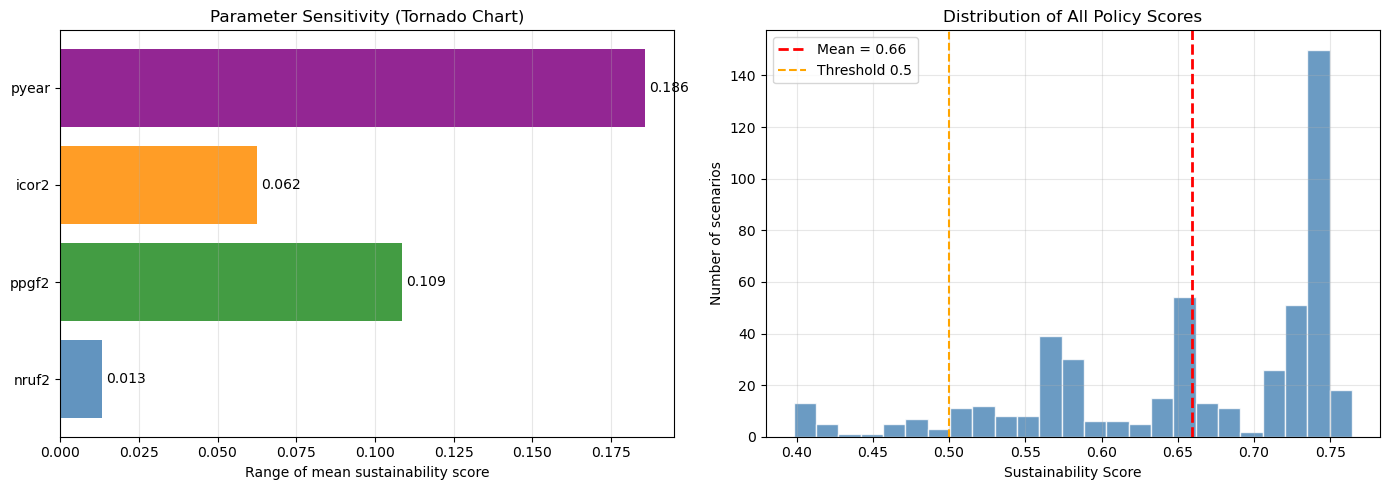

Most influential: pyear
Scenarios > 0.5: 466/500
Scenarios > 0.7: 245/500


In [87]:
# Sensitivity: which parameter matters most
sensitivity = {p: (lambda g: g.max()-g.min())(df.groupby(p)['total'].mean())
               for p in ['nruf2','ppgf2','icor2','pyear']}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(list(sensitivity.keys()), list(sensitivity.values()),
                    color=['steelblue','forestgreen','darkorange','purple'], alpha=0.85)
axes[0].bar_label(bars, fmt='%.3f', padding=3)
axes[0].set_xlabel('Range of mean sustainability score')
axes[0].set_title('Parameter Sensitivity (Tornado Chart)')
axes[0].grid(alpha=0.3, axis='x')

axes[1].hist(df['total'].dropna(), bins=25,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['total'].mean(), color='red', ls='--', lw=2,
                label=f'Mean = {df["total"].mean():.2f}')
axes[1].axvline(0.5, color='orange', ls='--', lw=1.5, label='Threshold 0.5')
axes[1].set_xlabel('Sustainability Score')
axes[1].set_ylabel('Number of scenarios')
axes[1].set_title('Distribution of All Policy Scores')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('network_selected_search_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most influential: {max(sensitivity, key=sensitivity.get)}')
print(f'Scenarios > 0.5: {(df["total"]>0.5).sum()}/{len(df)}')
print(f'Scenarios > 0.7: {(df["total"]>0.7).sum()}/{len(df)}')


Optimal policy  score=0.764
nruf2=0.1  ppgf2=0.1  icor2=4.0  pyear=1985


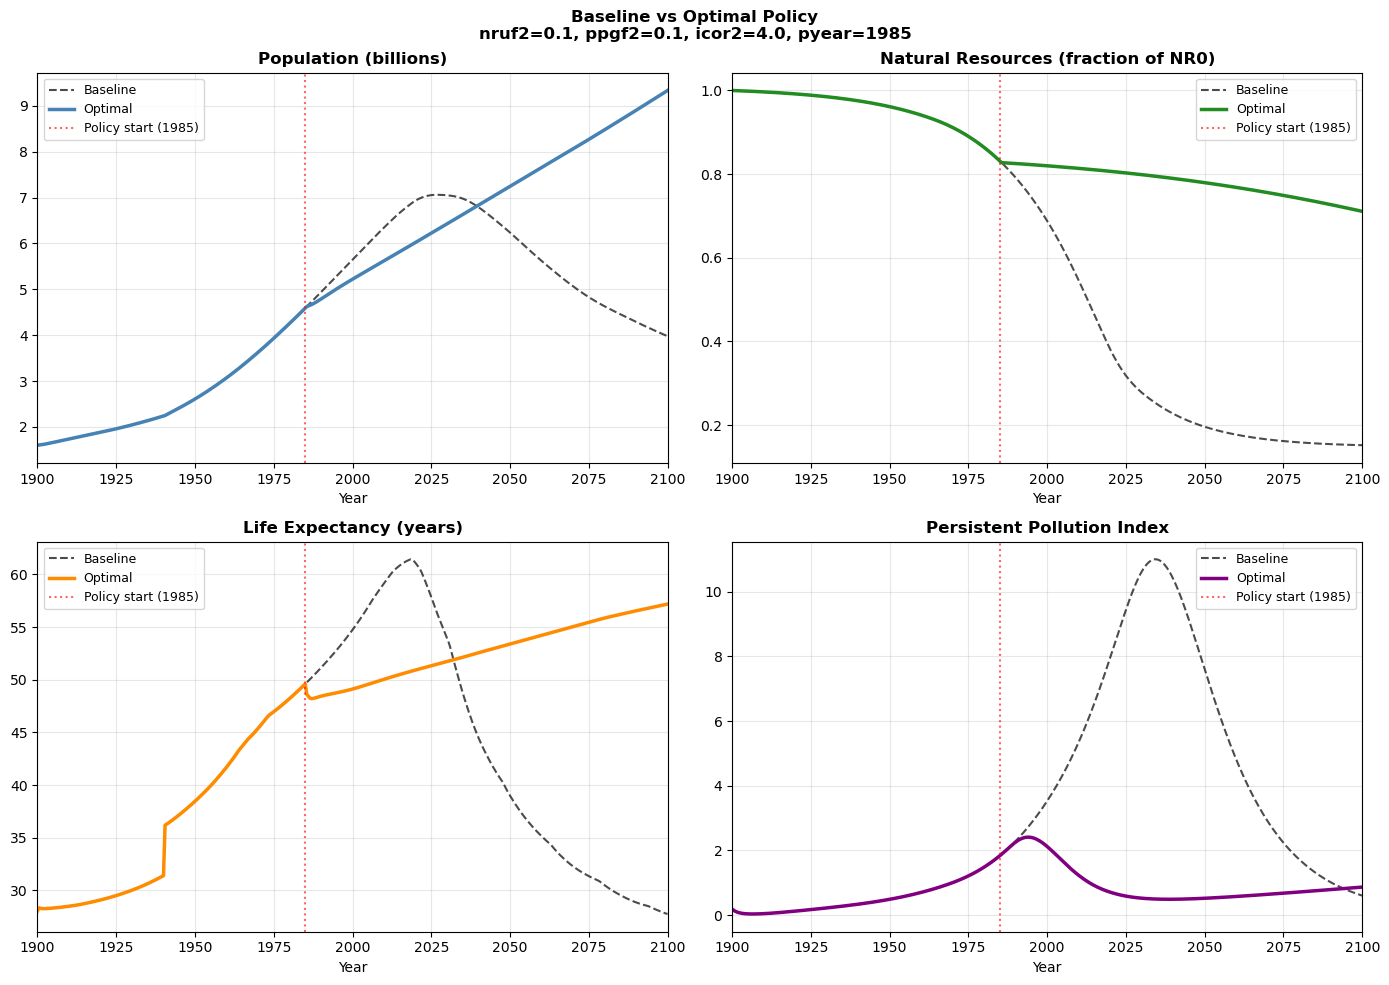

In [88]:
best    = df.iloc[0]
optimal = run_world3(pyear=int(best['pyear']),
                     nruf2=best['nruf2'], ppgf2=best['ppgf2'], icor2=best['icor2'])

print(f'Optimal policy  score={best["total"]:.3f}')
print(f'nruf2={best["nruf2"]}  ppgf2={best["ppgf2"]}  icor2={best["icor2"]}  pyear={int(best["pyear"])}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Baseline vs Optimal Policy\n'
             f'nruf2={best["nruf2"]}, ppgf2={best["ppgf2"]}, '
             f'icor2={best["icor2"]}, pyear={int(best["pyear"])}',
             fontsize=12, fontweight='bold')

plots = [
    ('pop',   1e9,            'Population (billions)',               'steelblue'),
    ('nr',    baseline.nr[0], 'Natural Resources (fraction of NR0)', 'forestgreen'),
    ('le',    1,              'Life Expectancy (years)',             'darkorange'),
    ('ppolx', 1,              'Persistent Pollution Index',          'purple'),
]
for ax, (var, scale, title, color) in zip(axes.flat, plots):
    ax.plot(t, getattr(baseline, var)/scale, 'k--', lw=1.5, alpha=0.7, label='Baseline')
    ax.plot(t, getattr(optimal,  var)/scale, color=color, lw=2.5, label='Optimal')
    ax.axvline(best['pyear'], color='red', ls=':', alpha=0.6,
               label=f'Policy start ({int(best["pyear"])})')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Year')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig('network_selected_optimal_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


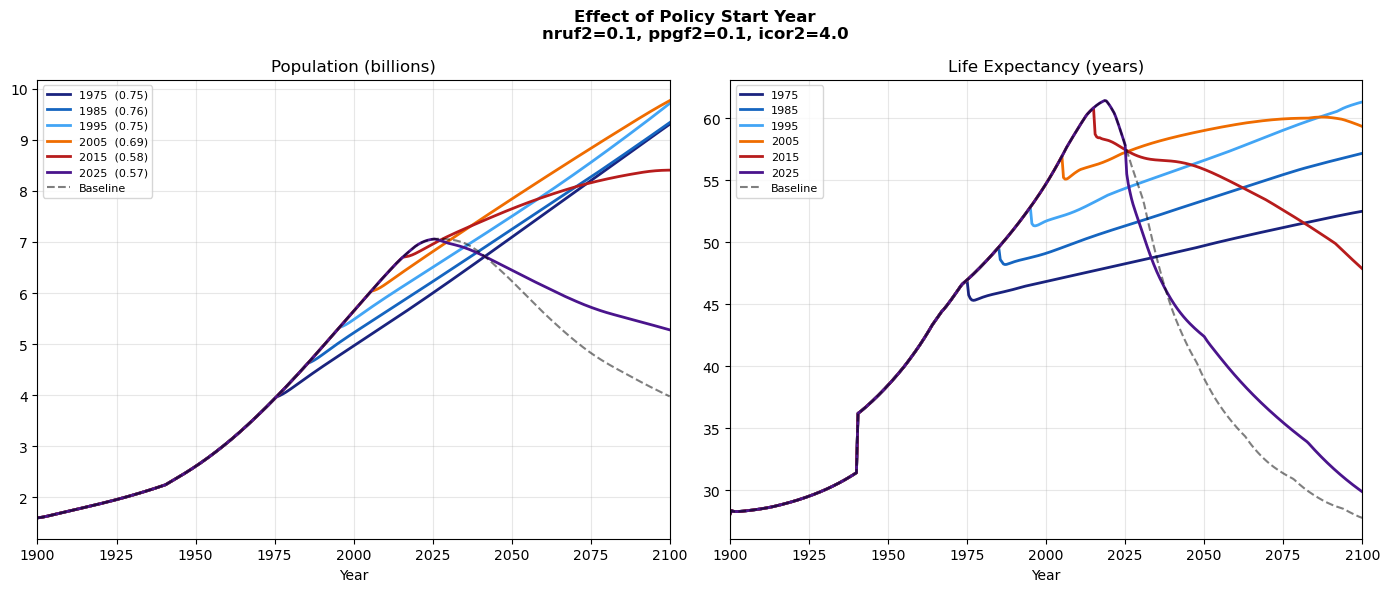

In [89]:
years  = [1975, 1985, 1995, 2005, 2015, 2025]
colors = ['#1a237e','#1565c0','#42a5f5','#ef6c00','#b71c1c','#4a148c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Effect of Policy Start Year\n'
             f'nruf2={best["nruf2"]}, ppgf2={best["ppgf2"]}, icor2={best["icor2"]}',
             fontsize=12, fontweight='bold')

for yr, col in zip(years, colors):
    m = run_world3(pyear=yr, nruf2=best['nruf2'],
                   ppgf2=best['ppgf2'], icor2=best['icor2'])
    s = sustainability_score(m)
    axes[0].plot(t, m.pop/1e9, color=col, lw=2,
                 label=f'{yr}  ({s["total"]:.2f})')
    axes[1].plot(t, m.le, color=col, lw=2, label=str(yr))

for ax, var, scale, title in [
    (axes[0], 'pop', 1e9, 'Population (billions)'),
    (axes[1], 'le',  1,   'Life Expectancy (years)')]:
    ax.plot(t, getattr(baseline, var)/scale, 'k--', lw=1.5, alpha=0.5, label='Baseline')
    ax.set_title(title); ax.set_xlabel('Year')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(1900, 2100)

plt.tight_layout()
plt.savefig('network_selected_timing_effect.png', dpi=150, bbox_inches='tight')
plt.show()


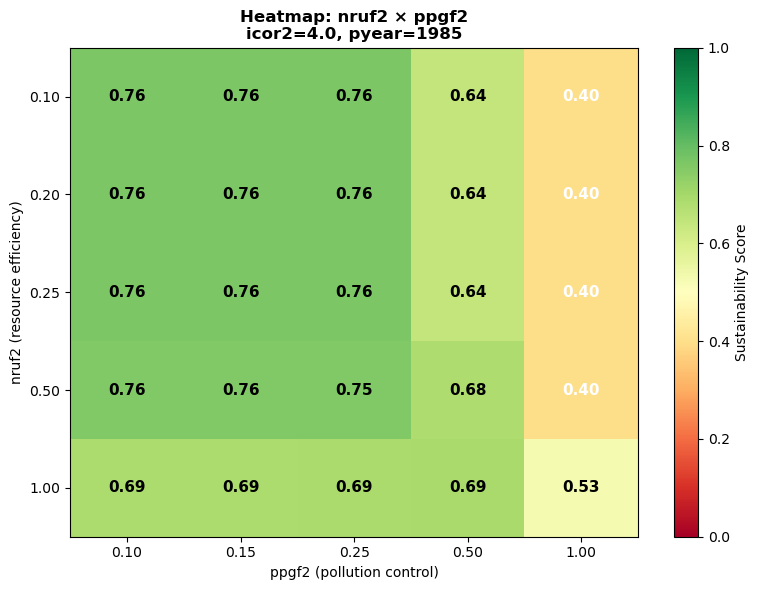

In [90]:
sub   = df[(df['icor2'] == best['icor2']) & (df['pyear'] == best['pyear'])]
pivot = sub.pivot_table(index='nruf2', columns='ppgf2', values='total', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
ax.set_xlabel('ppgf2 (pollution control)')
ax.set_ylabel('nruf2 (resource efficiency)')
ax.set_title(f'Heatmap: nruf2 × ppgf2\n'
             f'icor2={best["icor2"]}, pyear={int(best["pyear"])}',
             fontweight='bold')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white' if v < 0.45 else 'black')
plt.colorbar(im, ax=ax, label='Sustainability Score')
plt.tight_layout()
plt.savefig('network_selected_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8: Summary

This notebook does not perform a new leverage-point selection step. The grid-search parameters are fixed in advance from `final/candidates_selection.ipynb`, and the work here begins from that adopted four-parameter set.

The substantive tasks of the notebook are:
1. justify the sustainability indicators with baseline, correlation, and discrimination analysis
2. define the current sustainability score in full detail
3. run the fixed 600-scenario grid search
4. evaluate the highest-scoring policy bundle with trajectory, sensitivity, and heatmap diagnostics


In [91]:
op = sustainability_score(optimal)
print('=== REPORT SUMMARY ===')
print(f'{"Metric":<25} {"Baseline":>10} {"Optimal":>10} {"Change":>10}')
print('-' * 57)
rows = [
    ('Total Score',          bs['total'],            op['total'],            ''),
    ('NR Remaining (%)',     bs['nr_remaining_pct'], op['nr_remaining_pct'], '%'),
    ('Max Pollution',        bs['max_pol'],          op['max_pol'],          ''),
    ('Life Exp 2050-2100',   bs['le_late'],          op['le_late'],          'yrs'),
    ('Population 2090+ (B)', bs['pop_2100_B'],       op['pop_2100_B'],       'B'),
]
for name, bv, ov, unit in rows:
    print(f'{name:<25} {bv:>10.2f} {ov:>10.2f} {ov-bv:>+9.2f} {unit}')

print(f'\nOptimal parameters: icor2={best["icor2"]}, pyear={int(best["pyear"])}, ppgf2={best["ppgf2"]}, nruf2={best["nruf2"]}')
print(f'Total scenarios: {len(df)}')
print(f'Score > 0.5:     {(df["total"]>0.5).sum()}')
print(f'Score > 0.7:     {(df["total"]>0.7).sum()}')


=== REPORT SUMMARY ===
Metric                      Baseline    Optimal     Change
---------------------------------------------------------
Total Score                     0.39       0.76     +0.37 
NR Remaining (%)               15.20      71.10    +55.90 %
Max Pollution                  11.00       2.41     -8.59 
Life Exp 2050-2100             31.99      55.39    +23.40 yrs
Population 2090+ (B)            4.13       9.12     +4.99 B

Optimal parameters: icor2=4.0, pyear=1985, ppgf2=0.1, nruf2=0.1
Total scenarios: 500
Score > 0.5:     466
Score > 0.7:     245
